# Fake News Detection with DistilRoBERTa on Amazon SageMaker

Fine-tunes `distilroberta-base` on a merged dataset for binary fake news classification. The pipeline covers data loading, tokenization, SageMaker training, evaluation, and endpoint deployment.

## 1. Install Dependencies

In [ ]:
!pip install wordcloud
!pip install --upgrade accelerate

## 2. Import Libraries

In [ ]:
import io
from io import StringIO
from io import BytesIO
import os
import re
import tarfile
import time
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.gridspec import GridSpec
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from IPython.display import Image


import torch
from sklearn.utils.class_weight import compute_class_weight

import boto3
import sagemaker
from sagemaker import get_execution_role
from sagemaker.huggingface import HuggingFace, HuggingFaceModel
from sagemaker.serverless import ServerlessInferenceConfig
from sagemaker.s3 import S3Downloader


from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import gc

## 3. Initialize SageMaker Session

Retrieve the IAM execution role and default S3 bucket for this session.

In [11]:
sagemaker_session = sagemaker.Session()
role   = get_execution_role()
bucket = sagemaker_session.default_bucket()

print(f"SageMaker role: {role}")
print(f"Default bucket: {bucket}")

SageMaker role: arn:aws:iam::340825717285:role/service-role/AmazonSageMaker-ExecutionRole-20260403T181220
Default bucket: sagemaker-us-east-1-340825717285


## 4. Load Data 

Read the train, test, and validation splits of the dataset from S3. Text has been pre-cleaned: source tags stripped from the start, punctuation removed.

In [ ]:
# S3 paths
train_file = "s3://dataset-combined/train_combined.csv"
test_file  = "s3://dataset-combined/test_combined.csv"
valid_file = "s3://dataset-combined/validation_combined.csv"

# local output folder
local_dir = "data"
os.makedirs(local_dir, exist_ok=True)

print("Downloading files from S3 to local folder...")

S3Downloader.download(train_file, local_dir)
S3Downloader.download(test_file, local_dir)
S3Downloader.download(valid_file, local_dir)

print("Downloaded files:")
print(os.listdir(local_dir))

# local file paths
train_path = os.path.join(local_dir, "train_combined.csv")
test_path  = os.path.join(local_dir, "test_combined.csv")
valid_path = os.path.join(local_dir, "validation_combined.csv")

print("Loading local CSV files...")

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)
valid_df = pd.read_csv(valid_path)

# fill missing text and drop incomplete rows
train_df["text"] = train_df["text"].fillna("")
test_df["text"]  = test_df["text"].fillna("")
valid_df["text"] = valid_df["text"].fillna("")

train_df = train_df[["text", "label"]].dropna()
test_df  = test_df[["text", "label"]].dropna()
valid_df = valid_df[["text", "label"]].dropna()

print(f"Loaded: {len(train_df)} train | {len(test_df)} test | {len(valid_df)} validation samples")
print(f"Columns: {train_df.columns.tolist()}")

print("Train sample:")
display(train_df.head())

print("Test sample:")
display(test_df.head())

print("Validation sample:")
display(valid_df.head())

Downloaded files:
['train_combined.csv', 'test_combined.csv', 'validation_combined.csv']
Loading local CSV files...
Loaded: 98820 train | 12580 test | 12108 validation samples
Columns: ['text', 'label']
Train sample:


,text,label
0,UK PM May to travel to Brussels for meetings w...,1
1,MILO: The Difference Between Conservatives and...,0
2,"An Evolving Sports City, Atlanta Chases a Cham...",0
3,Morgan Griffith fought for a plan that would h...,0
4,Sanders BLASTS Misogynist ‘Bernie Bro’ Fans: ‘...,1


Test sample:


,text,label
0,Trump says immigration bill cannot include 'ch...,0
1,IS MEGYN KELLY Planning To Leave FOX News? [VI...,0
2,A Top Republican Really Just Blamed Obama For ...,1
3,"U.N. decries Israel's killing of Gaza amputee,...",1
4,A photograph shows the Arch of Baal erected on...,1


Validation sample:


,text,label
0,U.S. says 'administrative error' blocked Indon...,0
1,AZ Cops Taser Veteran With PTSD Until His Hear...,0
2,SWISS ARMY CHIEF WARNS CITIZENS About Explosiv...,0
3,Republican George W. Bush on Monday will seek ...,1
4,EP #11: Patrick Henningsen LIVE – ‘Top Trump T...,1


## 5. Class Distribution Analysis

Examine the label distribution across all three splits to assess class balance.

Class Distribution Analysis

Training Set:
----------------------------------------
  Class 0 (Fake/False): 52675 samples (53.30%)
  Class 1 (True/Real): 46145 samples (46.70%)

  Minority class : Class 1 (True/Real) (46145 samples)
  Majority class : Class 0 (Fake/False) (52675 samples)
  Imbalance ratio: 1.14x

Test Set:
----------------------------------------
  Class 0 (Fake/False):  6727 samples (53.47%)
  Class 1 (True/Real):  5853 samples (46.53%)

  Minority class : Class 1 (True/Real) (5853 samples)
  Majority class : Class 0 (Fake/False) (6727 samples)
  Imbalance ratio: 1.15x

Validation Set:
----------------------------------------
  Class 0 (Fake/False):  6432 samples (53.12%)
  Class 1 (True/Real):  5676 samples (46.88%)

  Minority class : Class 1 (True/Real) (5676 samples)
  Majority class : Class 0 (Fake/False) (6432 samples)
  Imbalance ratio: 1.13x


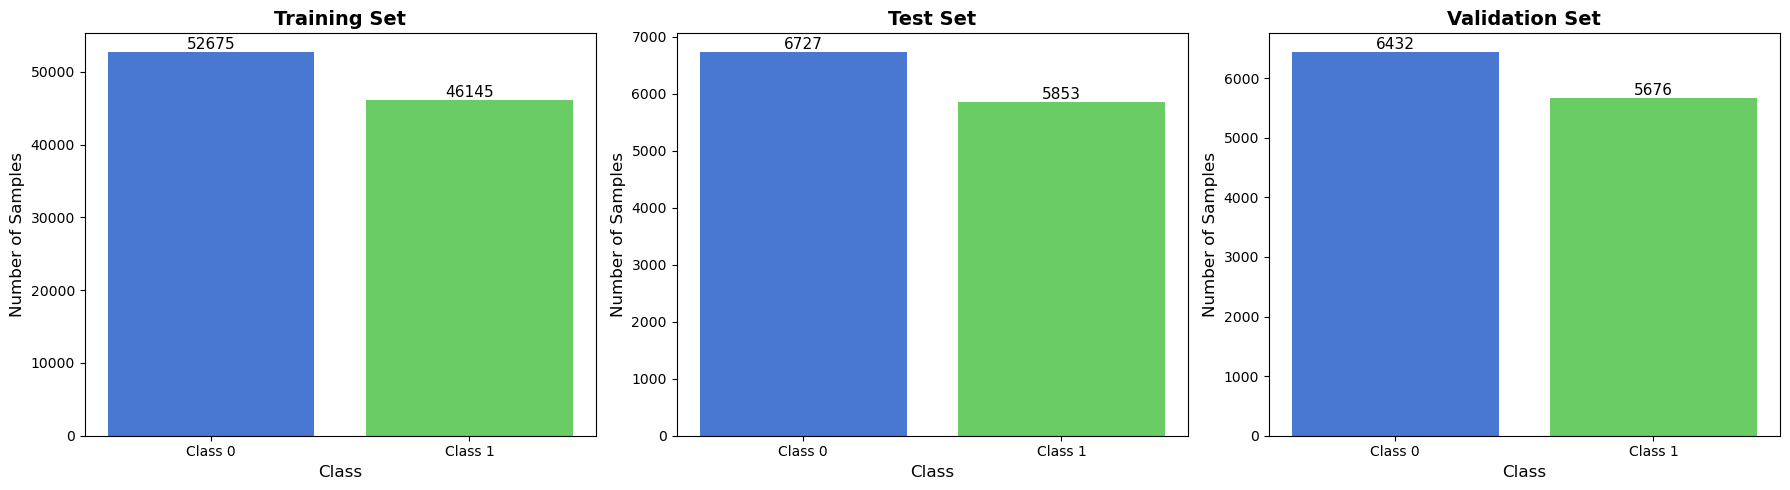


Class Weights for Weighted Loss
  Class 0: 0.9380
  Class 1: 1.0708


In [5]:
CLASS_NAMES = {
    0: "Class 0 (Fake/False)",
    1: "Class 1 (True/Real)"
}

datasets_map = {
    "Training":   train_df,
    "Test":        test_df,
    "Validation": valid_df,
}

print("=" * 60)
print("Class Distribution Analysis")
print("=" * 60)

for split_name, df in datasets_map.items():
    class_dist = Counter(df["label"])
    total = len(df)

    print(f"\n{split_name} Set:")
    print("-" * 40)
    for class_id in sorted(class_dist):
        count = class_dist[class_id]
        pct   = (count / total) * 100
        print(f"  {CLASS_NAMES[class_id]}: {count:5d} samples ({pct:.2f}%)")

    min_class = min(class_dist.items(), key=lambda x: x[1])
    max_class = max(class_dist.items(), key=lambda x: x[1])
    ratio = max_class[1] / min_class[1]
    print(f"\n  Minority class : {CLASS_NAMES[min_class[0]]} ({min_class[1]} samples)")
    print(f"  Majority class : {CLASS_NAMES[max_class[0]]} ({max_class[1]} samples)")
    print(f"  Imbalance ratio: {ratio:.2f}x")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ["#4878CF", "#6ACC65"]

for idx, (split_name, df) in enumerate(datasets_map.items()):
    class_dist = Counter(df["label"])
    classes = sorted(class_dist)
    counts  = [class_dist[c] for c in classes]

    bars = axes[idx].bar(classes, counts, color=colors[: len(classes)])
    axes[idx].set_xlabel("Class", fontsize=12)
    axes[idx].set_ylabel("Number of Samples", fontsize=12)
    axes[idx].set_title(f"{split_name} Set", fontsize=14, fontweight="bold")
    axes[idx].set_xticks(classes)
    axes[idx].set_xticklabels([f"Class {c}" for c in classes])

    for bar, count in zip(bars, counts):
        axes[idx].text(
            bar.get_x() + bar.get_width() / 2.0,
            bar.get_height(),
            str(count),
            ha="center", va="bottom", fontsize=11
        )

plt.tight_layout()
plt.show()

y_train = train_df["label"].values
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

print("\n" + "=" * 60)
print("Class Weights for Weighted Loss")
print("=" * 60)
for class_id, weight in zip(sorted(np.unique(y_train)), class_weights):
    print(f"  Class {class_id}: {weight:.4f}")

## 6. Word Cloud — Real News

In [ ]:
df = train_df

text = " ".join(df[df.label == 1].text)
wc = WordCloud(
    max_words=2000,
    width=1600,
    height=700,
    stopwords=STOPWORDS
).generate(text)

plt.figure(figsize=(15, 15))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud for Label True")
plt.show()

## 7. Word Cloud — Fake News

In [ ]:
text = " ".join(df[df.label == 0].text)

wc = WordCloud(
    max_words=2000,
    width=1600,
    height=700,
    stopwords=STOPWORDS
).generate(text)

plt.figure(figsize=(15, 15))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud for Label False")
plt.show()

## 8. Build Hugging Face DatasetDict

Convert the pandas DataFrames into Hugging Face Dataset objects and wrap them in a DatasetDict.

In [6]:
dataset = DatasetDict({
    "train":      Dataset.from_pandas(train_df, preserve_index=False),
    "test":       Dataset.from_pandas(test_df,  preserve_index=False),
    "validation": Dataset.from_pandas(valid_df, preserve_index=False),
})

print("Hugging Face DatasetDict created:")
print(dataset)

Hugging Face DatasetDict created:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 98820
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12580
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 12108
    })
})


## 9. Define Hyperparameters and Metric Definitions

Set all training hyperparameters passed to the SageMaker job, along with the regex patterns used to extract metrics from the training log.

In [7]:
hyperparameters = {
    "model_name": "distilroberta-base",
    "tokenizer_name": "distilroberta-base",
    "num_labels": 2,

    # training
    "epochs": 5,
    "train_batch_size": 16,
    "eval_batch_size": 32,
    "gradient_accumulation_steps": 2,

    # optimization
    "learning_rate": 2e-5,
    "weight_decay": 0.05,
    "warmup_steps": 300,
    "max_seq_length": 512,

    # regularization
    "early_stopping_patience": 2,
    "label_smoothing": 0.05,
    "max_grad_norm": 1.0,

    # reproducibility
    "seed": 42,

    
    "s3_bucket": bucket
}
metric_definitions = [
    {
        "Name": "train_loss",
        "Regex": r"'loss': ([0-9]*\.?[0-9]+)"
    },
    {
        "Name": "eval_loss",
        "Regex": r"'eval_loss': ([0-9]*\.?[0-9]+)"
    },
    {
        "Name": "accuracy",
        "Regex": r"'eval_accuracy': ([0-9]*\.?[0-9]+)"
    },
    {
        "Name": "precision_weighted",
        "Regex": r"'eval_precision': ([0-9]*\.?[0-9]+)"
    },
    {
        "Name": "recall_weighted",
        "Regex": r"'eval_recall': ([0-9]*\.?[0-9]+)"
    },
    {
        "Name": "f1_weighted",
        "Regex": r"'eval_f1_weighted': ([0-9]*\.?[0-9]+)"
    },
    {
        "Name": "precision_macro",
        "Regex": r"'eval_precision_macro': ([0-9]*\.?[0-9]+)"
    },
    {
        "Name": "recall_macro",
        "Regex": r"'eval_recall_macro': ([0-9]*\.?[0-9]+)"
    },
    {
        "Name": "f1_macro",
        "Regex": r"'eval_f1_macro': ([0-9]*\.?[0-9]+)"
    },
    {
        "Name": "auc",
        "Regex": r"'eval_auc': ([0-9]*\.?[0-9]+)"
    },
    {
        "Name": "mcc",
        "Regex": r"'eval_mcc': (-?[0-9]*\.?[0-9]+)"
    },
    {
        "Name": "precision_fake",
        "Regex": r"'eval_precision_fake': ([0-9]*\.?[0-9]+)"
    },
    {
        "Name": "precision_real",
        "Regex": r"'eval_precision_real': ([0-9]*\.?[0-9]+)"
    },
    {
        "Name": "recall_fake",
        "Regex": r"'eval_recall_fake': ([0-9]*\.?[0-9]+)"
    },
    {
        "Name": "recall_real",
        "Regex": r"'eval_recall_real': ([0-9]*\.?[0-9]+)"
    },
    {
        "Name": "f1_fake",
        "Regex": r"'eval_f1_fake': ([0-9]*\.?[0-9]+)"
    },
    {
        "Name": "f1_real",
        "Regex": r"'eval_f1_real': ([0-9]*\.?[0-9]+)"
    },
]

print("Hyperparameters and metric definitions configured.")

Hyperparameters and metric definitions configured.


## 10. Initialize Tokenizer

Load the `distilroberta-base` tokenizer and define a batched tokenization function. Dynamic padding is applied per batch rather than padding all sequences to max length, reducing memory usage and speeding up training.

In [8]:
tokenizer = AutoTokenizer.from_pretrained("distilroberta-base")
max_seq_length = hyperparameters.get("max_seq_length", 512)
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=max_seq_length,
    )

print("Tokenizer loaded successfully.")

Tokenizer loaded successfully.


## 11. Tokenize Datasets

Apply the tokenizer to all three splits. The `label` column is renamed to `labels` as required by the Hugging Face Trainer. Padding is handled dynamically by `DataCollatorWithPadding`.

In [9]:
print("Tokenizing datasets")



print("Tokenizing train...")
train_dataset = dataset["train"].map(
    tokenize,
    batched=True,
    batch_size=200,
    writer_batch_size=500,
    remove_columns=["text"],
    load_from_cache_file=False,
)

train_dataset = train_dataset.rename_column("label", "labels")
gc.collect()

print("Tokenizing validation...")
val_dataset = dataset["validation"].map(
    tokenize,
    batched=True,
    batch_size=200,
    writer_batch_size=500,
    remove_columns=["text"],
    load_from_cache_file=False,
)

val_dataset = val_dataset.rename_column("label", "labels")
gc.collect()

print("Tokenizing test...")
test_dataset = dataset["test"].map(
    tokenize,
    batched=True,
    batch_size=200,
    writer_batch_size=500,
    remove_columns=["text"],
    load_from_cache_file=False,
)

test_dataset = test_dataset.rename_column("label", "labels")
gc.collect()

print("Tokenization complete.")
print("Train columns:", train_dataset.column_names)
print("Validation columns:", val_dataset.column_names)
print("Test columns:", test_dataset.column_names)

Parameter 'function'=<function tokenize at 0x7fe645303600> of the transform datasets.arrow_dataset.Dataset._map_single couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only showed once. Subsequent hashing failures won't be showed.


Tokenizing datasets
Tokenizing train...


  0%|          | 0/495 [00:00<?, ?ba/s]

Tokenizing validation...


  0%|          | 0/61 [00:00<?, ?ba/s]

Tokenizing test...


  0%|          | 0/63 [00:00<?, ?ba/s]

Tokenization complete.
Train columns: ['labels', 'input_ids', 'attention_mask']
Validation columns: ['labels', 'input_ids', 'attention_mask']
Test columns: ['labels', 'input_ids', 'attention_mask']


## 12. Upload Tokenized Datasets to S3

Serialize each split to disk using the Hugging Face `save_to_disk` format and upload to S3 for the SageMaker training job to consume.

In [10]:
s3_prefix  = "final-v/tokenized"
s3_client  = boto3.client("s3")

train_path = f"s3://{bucket}/{s3_prefix}/train"
test_path  = f"s3://{bucket}/{s3_prefix}/test"
val_path   = f"s3://{bucket}/{s3_prefix}/valid"

print("Saving tokenized datasets to S3...")

for split_name, ds in [("train", train_dataset), ("test", test_dataset), ("valid", val_dataset)]:
    local_path = f"/tmp/final-v_{split_name}"
    print(f"  Saving {split_name}...")
    ds.save_to_disk(local_path)

    s3_path = f"{s3_prefix}/{split_name}"
    for root, dirs, files in os.walk(local_path):
        for file in files:
            local_file = os.path.join(root, file)
            s3_file = os.path.join(s3_path, os.path.relpath(local_file, local_path))
            s3_client.upload_file(local_file, bucket, s3_file)

    print(f"  Uploaded to s3://{bucket}/{s3_path}")

print("\nAll datasets saved to S3.")

Saving tokenized datasets to S3...
  Saving train...
  Uploaded to s3://sagemaker-us-east-1-340825717285/final-v/tokenized/train
  Saving test...
  Uploaded to s3://sagemaker-us-east-1-340825717285/final-v/tokenized/test
  Saving valid...
  Uploaded to s3://sagemaker-us-east-1-340825717285/final-v/tokenized/valid

All datasets saved to S3.


## 13. Configure the HuggingFace Estimator

Define the SageMaker HuggingFace estimator using `train-final-v.py` as the entry point.

In [11]:
training_job_name = f"distilroberta-final-v-{int(time.time())}"

huggingface_estimator = HuggingFace(
    entry_point="train-final-v.py",
    source_dir="scripts",
    instance_type="ml.g4dn.xlarge",
    instance_count=1,
    role=role,
    transformers_version="4.26.0",
    pytorch_version="1.13.1",
    py_version="py39",
    hyperparameters=hyperparameters,
    metric_definitions=metric_definitions,
    max_run=36000,
)

print(f"Training job name: {training_job_name}")

Training job name: distilroberta-final-v-1777726200


## 14. Launch Training Job

Submit the training job to SageMaker. The job streams logs to the notebook until completion.

In [12]:
huggingface_estimator.fit(
    {
        "train":      train_path,
        "test":       test_path,
        "validation": val_path,
    },
    wait=True,
    job_name=training_job_name,
)

INFO:sagemaker.image_uris:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.
INFO:sagemaker:Creating training-job with name: distilroberta-final-v-1777726200


2026-05-02 12:50:20 Starting - Starting the training job...
2026-05-02 12:50:35 Starting - Preparing the instances for training...
2026-05-02 12:51:01 Downloading - Downloading input data...
2026-05-02 12:51:32 Downloading - Downloading the training image..................
2026-05-02 12:54:34 Training - Training image download completed. Training in progress.bash: cannot set terminal process group (-1): Inappropriate ioctl for device
bash: no job control in this shell
/opt/conda/lib/python3.9/site-packages/paramiko/pkey.py:100: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
/opt/conda/lib/python3.9/site-packages/paramiko/transport.py:259: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,
2

## 15. Retrieve Training Metrics

Query the SageMaker API for the most recent completed training job, print final evaluation metrics, and download output artifacts from S3.

In [ ]:
sm = boto3.client("sagemaker")
s3 = boto3.client("s3")

# find the most recent completed training job
response = sm.list_training_jobs(
    MaxResults=20,
    SortBy="CreationTime",
    SortOrder="Descending",
)

job_name = None

for job in response["TrainingJobSummaries"]:
    if (
        "distilroberta-final-v" in job["TrainingJobName"]
        and job["TrainingJobStatus"] == "Completed"
    ):
        job_name = job["TrainingJobName"]
        job_details = sm.describe_training_job(TrainingJobName=job_name)
        latest_model_data = job_details["ModelArtifacts"]["S3ModelArtifacts"]

        print(f"Job   : {job_name}")
        print(f"Model : {latest_model_data}")

        print("\nFinal metrics from SageMaker:")
        for metric in job_details.get("FinalMetricDataList", []):
            print(f"  {metric['MetricName']}: {metric['Value']:.4f}")

        print("\n" + "-" * 60)
        break


if job_name is None:
    print("No completed training job found")

else:
    # download and extract output.tar.gz
    key = f"{job_name}/output/output.tar.gz"

    response = s3.get_object(Bucket=bucket, Key=key)
    tar_buffer = BytesIO(response["Body"].read())

    extract_dir = "/tmp/sm_output_final_v"
    os.makedirs(extract_dir, exist_ok=True)

    with tarfile.open(fileobj=tar_buffer, mode="r:gz") as tar:
        tar.extractall(path=extract_dir)

    print(f"\nExtracted to: {extract_dir}")

    print("\nExtracted files:")
    for file_name in os.listdir(extract_dir):
        print(f"  - {file_name}")


    # load test metrics
    test_metrics = {}

    eval_csv_path = os.path.join(extract_dir, "eval_results.csv")

    if os.path.exists(eval_csv_path):
        df_eval = pd.read_csv(eval_csv_path)
        row = df_eval.iloc[0].to_dict()

        test_metrics = {
            "accuracy": row.get("eval_accuracy", 0),
            "weighted_f1": row.get("eval_f1_weighted", 0),
            "macro_f1": row.get("eval_f1_macro", 0),
            "precision_weighted": row.get("eval_precision", 0),
            "recall_weighted": row.get("eval_recall", 0),
            "precision_macro": row.get("eval_precision_macro", 0),
            "recall_macro": row.get("eval_recall_macro", 0),
            "auc": row.get("eval_auc", 0),
            "mcc": row.get("eval_mcc", 0),
            "loss": row.get("eval_loss", 0),
            "precision_fake": row.get("eval_precision_fake", 0),
            "precision_real": row.get("eval_precision_real", 0),
            "recall_fake": row.get("eval_recall_fake", 0),
            "recall_real": row.get("eval_recall_real", 0),
            "f1_fake": row.get("eval_f1_fake", 0),
            "f1_real": row.get("eval_f1_real", 0),
        }

        print("\nLoaded test metrics.")
    else:
        print("\nMissing eval_results.csv")


    # load training runtime
    train_metrics = {}

    train_csv_path = os.path.join(extract_dir, "train_results.csv")

    if os.path.exists(train_csv_path):
        df_train = pd.read_csv(train_csv_path)
        row = df_train.iloc[0].to_dict()

        train_metrics = {
            "train_runtime": row.get("train_runtime", 0),
            "train_samples_per_second": row.get("train_samples_per_second", 0),
            "train_steps_per_second": row.get("train_steps_per_second", 0),
            "train_loss": row.get("train_loss", 0),
        }

        print("Loaded training metrics.")
    else:
        print("Missing train_results.csv")


    # load validation metrics from training history best validation by macro f1
    val_metrics = {}

    history_csv_path = os.path.join(extract_dir, "training_history.csv")

    if os.path.exists(history_csv_path):
        df_history = pd.read_csv(history_csv_path)

        if "eval_f1_macro" in df_history.columns:
            val_rows = df_history[df_history["eval_f1_macro"].notna()]

            if not val_rows.empty:
                best_val = val_rows.loc[val_rows["eval_f1_macro"].idxmax()]

                val_metrics = {
                    "best_step": best_val.get("step", 0),
                    "accuracy": best_val.get("eval_accuracy", 0),
                    "weighted_f1": best_val.get("eval_f1_weighted", 0),
                    "macro_f1": best_val.get("eval_f1_macro", 0),
                    "precision_weighted": best_val.get("eval_precision", 0),
                    "recall_weighted": best_val.get("eval_recall", 0),
                    "precision_macro": best_val.get("eval_precision_macro", 0),
                    "recall_macro": best_val.get("eval_recall_macro", 0),
                    "auc": best_val.get("eval_auc", 0),
                    "mcc": best_val.get("eval_mcc", 0),
                    "loss": best_val.get("eval_loss", 0),
                    "precision_fake": best_val.get("eval_precision_fake", 0),
                    "precision_real": best_val.get("eval_precision_real", 0),
                    "recall_fake": best_val.get("eval_recall_fake", 0),
                    "recall_real": best_val.get("eval_recall_real", 0),
                    "f1_fake": best_val.get("eval_f1_fake", 0),
                    "f1_real": best_val.get("eval_f1_real", 0),
                }

                print("Loaded validation metrics from best Macro F1.")
            else:
                print("No validation rows found in training_history.csv")
        else:
            print("Column eval_f1_macro not found in training_history.csv")
    else:
        print("Missing training_history.csv")


    # load classification report
    report = []

    report_csv_path = os.path.join(extract_dir, "classification_report.csv")

    if os.path.exists(report_csv_path):
        df_report = pd.read_csv(report_csv_path)
        report = df_report.to_dict("records")
        print("Loaded classification report.")
    else:
        print("Missing classification_report.csv")


    # print training runtime
    print("\n" + "=" * 60)
    print("TRAINING RUNTIME")
    print("=" * 60)
    print(f"runtime seconds        : {train_metrics.get('train_runtime', 0):.2f}")
    print(f"runtime minutes        : {train_metrics.get('train_runtime', 0) / 60:.2f}")
    print(f"samples per second     : {train_metrics.get('train_samples_per_second', 0):.5f}")
    print(f"steps per second       : {train_metrics.get('train_steps_per_second', 0):.5f}")
    print(f"train loss             : {train_metrics.get('train_loss', 0):.5f}")


    # print validation results
    print("\n" + "=" * 60)
    print("VALIDATION RESULTS - BEST MACRO F1")
    print("=" * 60)
    print(f"best step              : {val_metrics.get('best_step', 0)}")
    print(f"accuracy               : {val_metrics.get('accuracy', 0):.5f}")
    print(f"weighted f1            : {val_metrics.get('weighted_f1', 0):.5f}")
    print(f"macro f1               : {val_metrics.get('macro_f1', 0):.5f}")
    print(f"precision weighted     : {val_metrics.get('precision_weighted', 0):.5f}")
    print(f"recall weighted        : {val_metrics.get('recall_weighted', 0):.5f}")
    print(f"precision macro        : {val_metrics.get('precision_macro', 0):.5f}")
    print(f"recall macro           : {val_metrics.get('recall_macro', 0):.5f}")
    print(f"auc                    : {val_metrics.get('auc', 0):.5f}")
    print(f"mcc                    : {val_metrics.get('mcc', 0):.5f}")
    print(f"loss                   : {val_metrics.get('loss', 0):.5f}")

    print("\n" + "-" * 60)
    print("VALIDATION PER-CLASS")
    print("-" * 60)
    print(f"fake precision         : {val_metrics.get('precision_fake', 0):.5f}")
    print(f"fake recall            : {val_metrics.get('recall_fake', 0):.5f}")
    print(f"fake f1                : {val_metrics.get('f1_fake', 0):.5f}")
    print(f"real precision         : {val_metrics.get('precision_real', 0):.5f}")
    print(f"real recall            : {val_metrics.get('recall_real', 0):.5f}")
    print(f"real f1                : {val_metrics.get('f1_real', 0):.5f}")


    # print test results
    print("\n" + "=" * 60)
    print("TEST RESULTS")
    print("=" * 60)
    print(f"accuracy               : {test_metrics.get('accuracy', 0):.5f}")
    print(f"weighted f1            : {test_metrics.get('weighted_f1', 0):.5f}")
    print(f"macro f1               : {test_metrics.get('macro_f1', 0):.5f}")
    print(f"precision weighted     : {test_metrics.get('precision_weighted', 0):.5f}")
    print(f"recall weighted        : {test_metrics.get('recall_weighted', 0):.5f}")
    print(f"precision macro        : {test_metrics.get('precision_macro', 0):.5f}")
    print(f"recall macro           : {test_metrics.get('recall_macro', 0):.5f}")
    print(f"auc                    : {test_metrics.get('auc', 0):.5f}")
    print(f"mcc                    : {test_metrics.get('mcc', 0):.5f}")
    print(f"loss                   : {test_metrics.get('loss', 0):.5f}")

    print("\n" + "-" * 60)
    print("TEST PER-CLASS")
    print("-" * 60)
    print(f"fake precision         : {test_metrics.get('precision_fake', 0):.5f}")
    print(f"fake recall            : {test_metrics.get('recall_fake', 0):.5f}")
    print(f"fake f1                : {test_metrics.get('f1_fake', 0):.5f}")
    print(f"real precision         : {test_metrics.get('precision_real', 0):.5f}")
    print(f"real recall            : {test_metrics.get('recall_real', 0):.5f}")
    print(f"real f1                : {test_metrics.get('f1_real', 0):.5f}")


    # print classification report
    if report:
        print("\n" + "=" * 60)
        print("CLASSIFICATION REPORT")
        print("=" * 60)

        for row in report:
            if row["Class"] in ["FAKE (0)", "REAL (1)", "macro avg", "weighted avg"]:
                print(
                    f"{row['Class']:<14} "
                    f"precision: {row['Precision']:.5f}  "
                    f"recall: {row['Recall']:.5f}  "
                    f"f1: {row['F1-score']:.5f}  "
                    f"support: {row['Support']:.0f}"
                )

Job   : distilroberta-final-v-1777726200
Model : s3://sagemaker-us-east-1-340825717285/distilroberta-final-v-1777726200/output/model.tar.gz

Final metrics from SageMaker:
  precision_fake: 0.9503
  precision_real: 0.9511
  accuracy: 0.9507
  recall_macro: 0.9503
  f1_fake: 0.9538
  f1_macro: 0.9505
  mcc: 0.9010
  precision_weighted: 0.9507
  auc: 0.9931
  recall_weighted: 0.9507
  recall_fake: 0.9572
  f1_weighted: 0.9507
  precision_macro: 0.9507
  train_loss: 0.1974
  eval_loss: 0.2008
  recall_real: 0.9433
  f1_real: 0.9472

------------------------------------------------------------

Extracted to: /tmp/sm_output_final_v

Extracted files:
  - confidence_distribution.png
  - eval_results.csv
  - f1_curve.png
  - loss_curve.png
  - accuracy_curve.png
  - confusion_matrix.png
  - train_results.csv
  - classification_report.csv
  - roc_curve.png
  - training_history.csv

Loaded test metrics.
Loaded training metrics.
Loaded validation metrics from best Macro F1.
Loaded classification r

/tmp/ipykernel_5650/1722822936.py:51: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_dir)


## 16. Evaluation Dashboard

Build and display the full evaluation figure including confusion matrix, ROC curve, classification report, loss curve, F1 curve, and confidence distribution.

Using job: distilroberta-final-v-1777726200


/tmp/ipykernel_7834/38188228.py:52: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_dir)


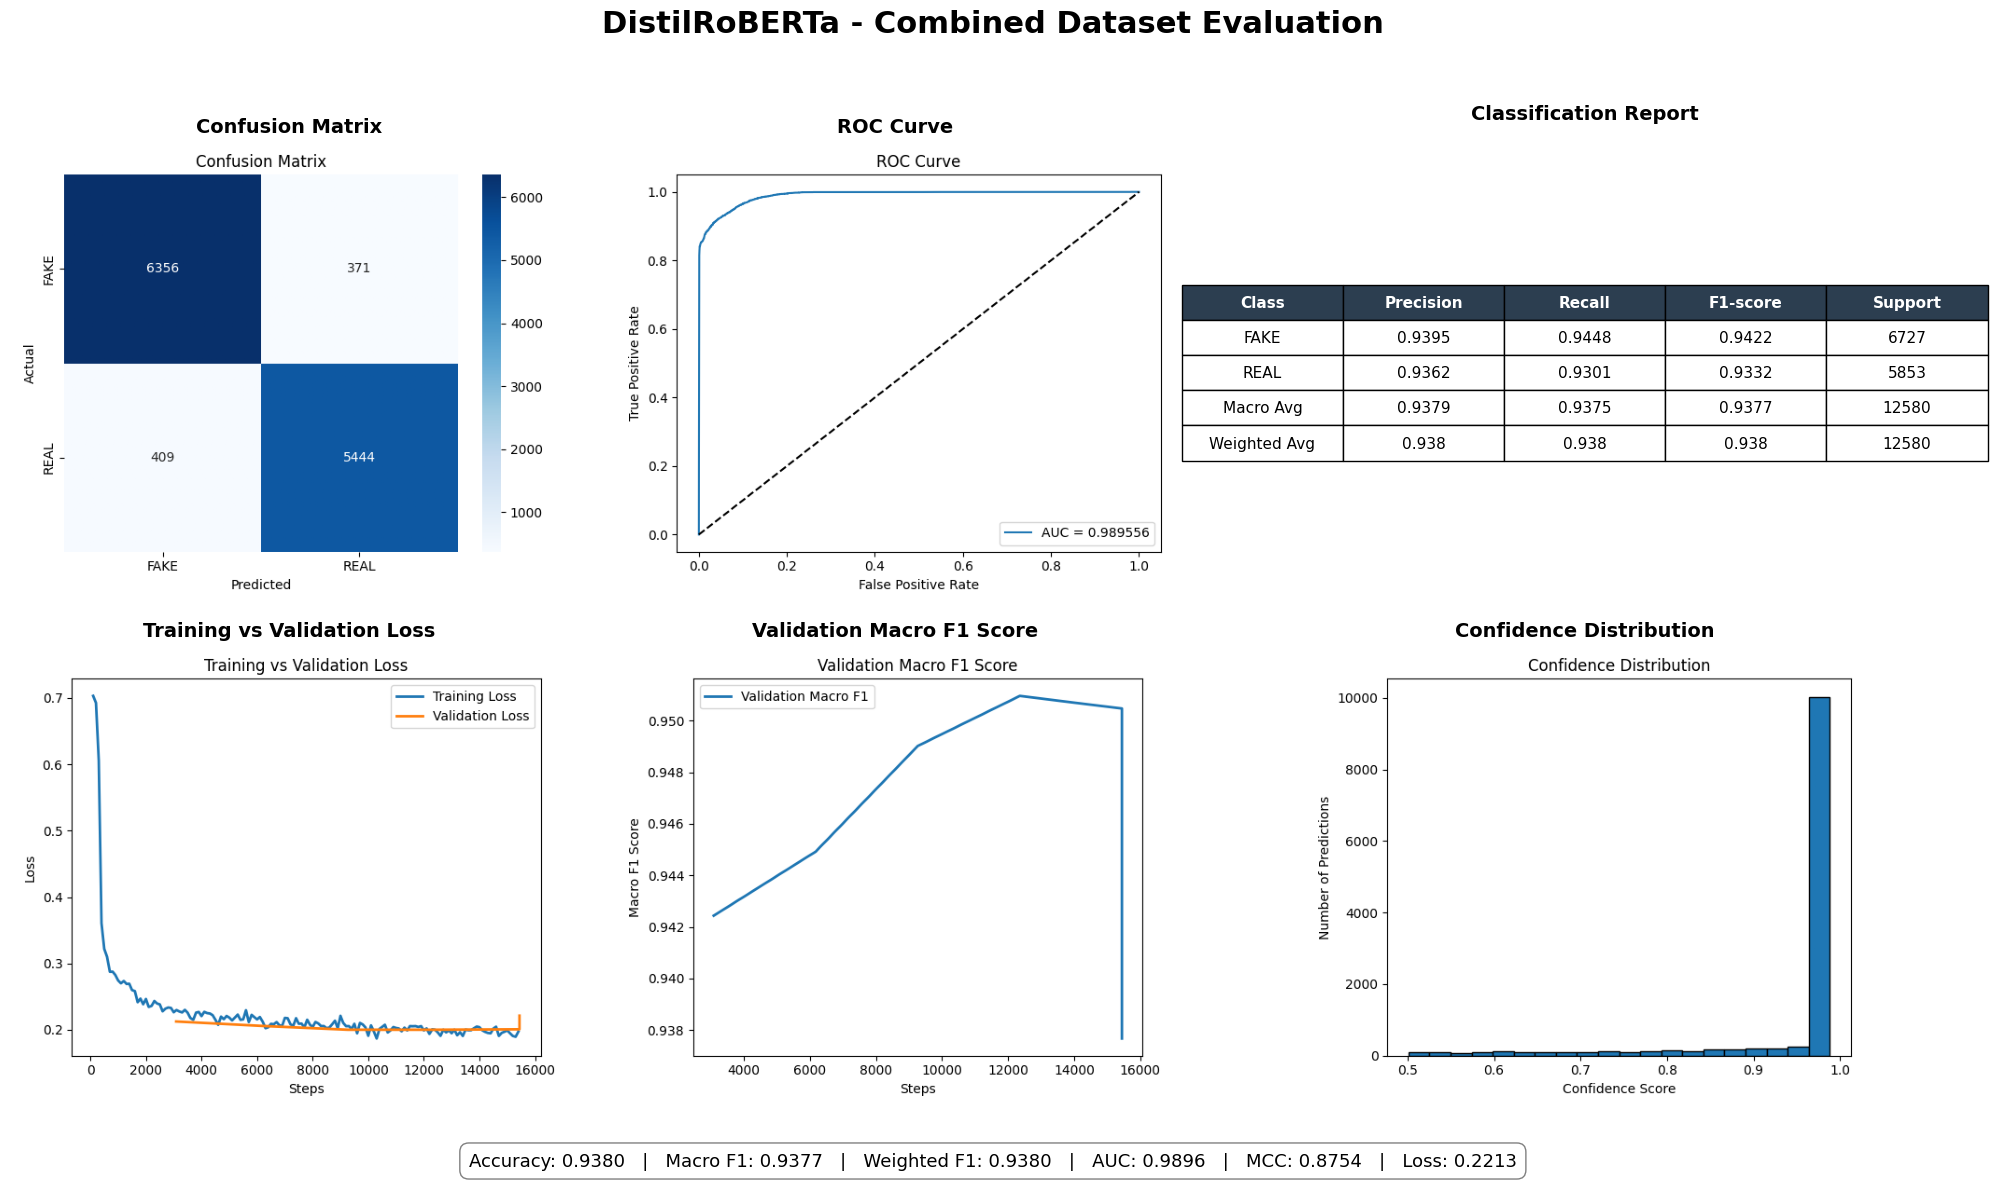

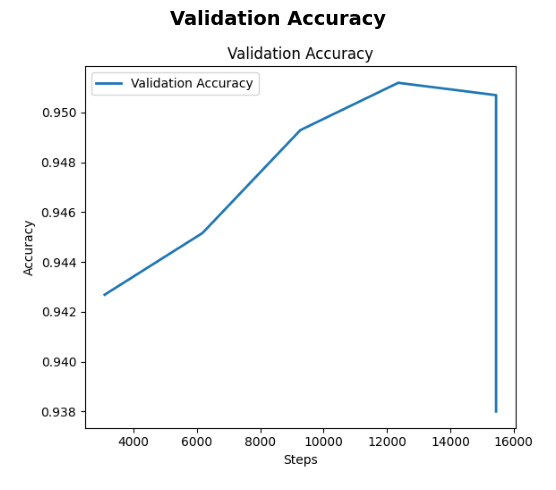

In [ ]:

JOB_PREFIX = "distilroberta-final-v"   
DASHBOARD_TITLE = "DistilRoBERTa - Combined Dataset Evaluation"

sagemaker_session = sagemaker.Session()
bucket = sagemaker_session.default_bucket()

sm = boto3.client("sagemaker")
s3 = boto3.client("s3")



# find latest completed job
response = sm.list_training_jobs(
    MaxResults=20,
    SortBy="CreationTime",
    SortOrder="Descending",
)

job_name = None
latest_model_data = None

for job in response["TrainingJobSummaries"]:
    if (
        JOB_PREFIX in job["TrainingJobName"]
        and job["TrainingJobStatus"] == "Completed"
    ):
        job_name = job["TrainingJobName"]
        job_details = sm.describe_training_job(TrainingJobName=job_name)
        latest_model_data = job_details["ModelArtifacts"]["S3ModelArtifacts"]
        break


if job_name is None:
    print("No completed training job found.")

else:
    print(f"Using job: {job_name}")

    # download and extract output.tar.gz
    key = f"{job_name}/output/output.tar.gz"

    response = s3.get_object(Bucket=bucket, Key=key)
    tar_buffer = BytesIO(response["Body"].read())

    extract_dir = "/tmp/sm_output_dashboard"
    os.makedirs(extract_dir, exist_ok=True)

    with tarfile.open(fileobj=tar_buffer, mode="r:gz") as tar:
        tar.extractall(path=extract_dir)


    # load files
    eval_path = os.path.join(extract_dir, "eval_results.csv")
    train_path = os.path.join(extract_dir, "train_results.csv")
    history_path = os.path.join(extract_dir, "training_history.csv")
    report_path = os.path.join(extract_dir, "classification_report.csv")

    eval_df = pd.read_csv(eval_path) if os.path.exists(eval_path) else pd.DataFrame()
    train_df = pd.read_csv(train_path) if os.path.exists(train_path) else pd.DataFrame()
    history_df = pd.read_csv(history_path) if os.path.exists(history_path) else pd.DataFrame()
    report_df = pd.read_csv(report_path) if os.path.exists(report_path) else pd.DataFrame()


    def read_image(filename):
        path = os.path.join(extract_dir, filename)
        if os.path.exists(path):
            return mpimg.imread(path)
        return None

    def show_image(ax, filename, title):
        img = read_image(filename)

        if img is not None:
            ax.imshow(img)
            ax.set_title(title, fontsize=14, fontweight="bold")
            ax.axis("off")
        else:
            ax.text(
                0.5,
                0.5,
                f"Missing:\n{filename}",
                ha="center",
                va="center",
                fontsize=11
            )
            ax.set_title(title, fontsize=14, fontweight="bold")
            ax.axis("off")

    def get_metric(row, name):
        return row.get(name, 0)


    # prepare test metrics
    if not eval_df.empty:
        test_row = eval_df.iloc[0].to_dict()

        acc = get_metric(test_row, "eval_accuracy")
        auc_score = get_metric(test_row, "eval_auc")
        mcc = get_metric(test_row, "eval_mcc")
        macro_f1 = get_metric(test_row, "eval_f1_macro")
        weighted_f1 = get_metric(test_row, "eval_f1_weighted")
        test_loss = get_metric(test_row, "eval_loss")
    else:
        acc = auc_score = mcc = macro_f1 = weighted_f1 = test_loss = 0


    # prepare classification report table
    table_df = pd.DataFrame()

    if not report_df.empty:
        wanted_rows = ["FAKE (0)", "REAL (1)", "macro avg", "weighted avg"]
        table_df = report_df[report_df["Class"].isin(wanted_rows)].copy()

        table_df["Class"] = table_df["Class"].replace({
            "FAKE (0)": "FAKE",
            "REAL (1)": "REAL",
            "macro avg": "Macro Avg",
            "weighted avg": "Weighted Avg"
        })

        table_df = table_df[["Class", "Precision", "Recall", "F1-score", "Support"]]

        for col in ["Precision", "Recall", "F1-score"]:
            table_df[col] = table_df[col].astype(float).round(4)

        table_df["Support"] = table_df["Support"].astype(float).astype(int)

    
    # dashboard figure
    fig = plt.figure(figsize=(20, 12))
    gs = GridSpec(
        2,
        3,
        figure=fig,
        height_ratios=[1, 1],
        width_ratios=[1, 1, 1.3]
    )

    fig.suptitle(
        DASHBOARD_TITLE,
        fontsize=22,
        fontweight="bold",
        y=0.98
    )

    # confusion matrix
    ax1 = fig.add_subplot(gs[0, 0])
    show_image(ax1, "confusion_matrix.png", "Confusion Matrix")

    # roc curve
    ax2 = fig.add_subplot(gs[0, 1])
    show_image(ax2, "roc_curve.png", "ROC Curve")

    # classification report table
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.axis("off")
    ax3.set_title("Classification Report", fontsize=14, fontweight="bold", pad=15)

    if not table_df.empty:
        table = ax3.table(
            cellText=table_df.values,
            colLabels=table_df.columns,
            cellLoc="center",
            loc="center"
        )

        table.auto_set_font_size(False)
        table.set_fontsize(11)
        table.scale(1.1, 1.9)

        for j in range(len(table_df.columns)):
            table[0, j].set_text_props(fontweight="bold", color="white")
            table[0, j].set_facecolor("#2c3e50")
    else:
        ax3.text(
            0.5,
            0.5,
            "classification_report.csv not found",
            ha="center",
            va="center",
            fontsize=12
        )

    # loss curve
    ax4 = fig.add_subplot(gs[1, 0])
    show_image(ax4, "loss_curve.png", "Training vs Validation Loss")

    # macro f1 curve
    ax5 = fig.add_subplot(gs[1, 1])
    show_image(ax5, "f1_curve.png", "Validation Macro F1 Score")

    # confidence distribution
    ax6 = fig.add_subplot(gs[1, 2])
    show_image(ax6, "confidence_distribution.png", "Confidence Distribution")

    # footer metrics
    footer_text = (
        f"Accuracy: {acc:.4f}   |   "
        f"Macro F1: {macro_f1:.4f}   |   "
        f"Weighted F1: {weighted_f1:.4f}   |   "
        f"AUC: {auc_score:.4f}   |   "
        f"MCC: {mcc:.4f}   |   "
        f"Loss: {test_loss:.4f}"
    )

    fig.text(
        0.5,
        0.02,
        footer_text,
        ha="center",
        va="center",
        fontsize=13,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray")
    )

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

    accuracy_img = read_image("accuracy_curve.png")

    if accuracy_img is not None:
        plt.figure(figsize=(8, 5))
        plt.imshow(accuracy_img)
        plt.axis("off")
        plt.title("Validation Accuracy", fontsize=14, fontweight="bold")
        plt.tight_layout()
        plt.show()

## 17. Deploy Model to SageMaker Endpoint

Create a serverless inference endpoint from the trained model artifact. Any existing endpoint or endpoint config with the same name is deleted first.

In [13]:
session       = sagemaker.Session()
role          = get_execution_role()
sm            = boto3.client("sagemaker", region_name="us-east-1")
ENDPOINT_NAME = "distilroberta-fakenews-serverless-endpoint"

for delete_fn, kwargs in [
    (sm.delete_endpoint,        {"EndpointName":       ENDPOINT_NAME}),
    (sm.delete_endpoint_config, {"EndpointConfigName": ENDPOINT_NAME}),
]:
    try:
        delete_fn(**kwargs)
        print(f"Deleted: {list(kwargs.values())[0]}")
    except Exception:
        print(f"Resource not found (nothing to delete): {list(kwargs.values())[0]}")

model = HuggingFaceModel(
    model_data=latest_model_data,
    role=role,
    transformers_version="4.26.0",
    pytorch_version="1.13.1",
    py_version="py39",
)

serverless_config = ServerlessInferenceConfig(
    memory_size_in_mb=2048,
    max_concurrency=5,
)

predictor = model.deploy(
    serverless_inference_config=serverless_config,
    endpoint_name=ENDPOINT_NAME,
)

print(f"Serverless endpoint live: {predictor.endpoint_name}")

Deleted: distilroberta-fakenews-serverless-endpoint
Deleted: distilroberta-fakenews-serverless-endpoint
----!Serverless endpoint live: distilroberta-fakenews-serverless-endpoint
